# PulseFlow — Notebook de Investigação
### Nano-Challenge: Spotify Data | CBL aplicado à análise de dados

**Challenge statement:** gerar insights a partir do Spotify Dataset e entregar recomendações
baseadas em evidências, investigando se e como as características sonoras de uma faixa
permitem inferir sua adequação a um contexto de uso (treino, estudo, relaxamento, trabalho).

Este notebook cobre as **Fases 2 e 3** do plano de investigação do PulseFlow:
1. **Notebook base e ingestão** — carregar o dataset original, registrar shape, tipos, nulos e duplicatas.
2. **EDA** — distribuições, correlações, comparação por gênero/perfis e primeira checagem das hipóteses H1–H3.

> ⚠️ **Nota metodológica:** o dataset **não contém rótulos de contexto de uso** (treino, estudo, trabalho, relaxamento).
> Sempre que este notebook usar `track_genre` como *proxy* de contexto (ex.: `study`, `sleep`), isso é uma
> aproximação heurística para exploração inicial — **não é validação com usuários reais** (essa é a Fase 5).


## 1. Recap do Canvas (Objetivo de Negócio, ML e Escopo)

**Objetivo de negócio:** aumentar a adequação da experiência musical ao contexto atual do usuário
e reduzir o esforço/interações necessárias para trocar de conteúdo.
*Métricas de negócio candidatas:* % de recomendações adequadas ao contexto; nº de skips; tempo até o conteúdo desejado.

**Objetivo de ML:** classificar/ranquear músicas por adequação a contextos (Treino, Estudo, Relaxamento,
e futuramente Trabalho) usando as características sonoras do dataset.
*Métricas candidatas:* Macro F1 (classificação) e Precision@10 (ranking) — escolha final após definir a estratégia de rótulos.

**Escopo (TRATA):** recomendação/adaptação musical contextual usando características do Spotify Dataset,
preferências e contextos definidos pelo usuário.

**Escopo (NÃO TRATA nesta etapa):** diagnóstico médico, automação clínica, monitoramento contínuo por
smartwatch, detecção automática de conversa em produção, integração comercial com streaming.


## 2. Guiding Questions e Hipóteses em foco neste notebook

Priorização "Responder JÁ" (alto impacto / fácil): **GQ1, GQ2, GQ3**.

| GQ | Pergunta |
|---|---|
| **GQ1 – Dados** | Quais características musicais melhor diferenciam músicas para Treino, Estudo, Relaxamento e Trabalho? |
| **GQ2 – Usuário** | As preferências musicais de uma mesma pessoa mudam conforme a atividade? *(requer pesquisa com usuários — Fase 5, fora do escopo deste notebook)* |
| **GQ3 – Trabalho** | O perfil musical adequado para trabalho varia conforme o tipo de trabalho? *(idem — depende de rótulos de usuário)* |

Este notebook ataca diretamente **GQ1**, e prepara terreno para GQ2/GQ3 (que dependem de dados de usuário, não só do dataset).

**Hipóteses testadas (evidência do dataset via proxy de gênero):**

| Hipótese | Formulação |
|---|---|
| **H1 – Treino** | Músicas adequadas para treino tendem a ter `energy`, `tempo` e/ou `danceability` maiores. |
| **H2 – Estudo** | Músicas adequadas para estudo tendem a ter `speechiness` menor e `instrumentalness` maior. |
| **H3 – Relaxamento** | Músicas adequadas para relaxamento tendem a ter `energy` e `tempo` menores e `acousticness` maior. |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 30)


## 3. Fonte e descrição dos dados

**Origem:** `dataset.csv` — Spotify Dataset fornecido no desafio (Nano-Challenge: Spotify Data).
114.000 faixas, 21 colunas originais, cobrindo 114 gêneros musicais (1.000 faixas por gênero).

> Licença/origem: dataset acadêmico fornecido pelo material da disciplina (Slides_CBL_Spotify.pptx).
> Recomenda-se confirmar e citar a licença original (Kaggle *Spotify Tracks Dataset*) na versão final do notebook.


In [ ]:
from pathlib import Path

DATA_PATH = Path("dataset.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "O arquivo dataset.csv deve estar na mesma pasta do notebook."
    )

df_raw = pd.read_csv(DATA_PATH)

print("Dataset carregado com sucesso.")
print("Shape:", df_raw.shape)
df_raw.head(3)


In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

In [4]:
print("Colunas:", df_raw.columns.tolist())
print()
print("Gêneros únicos:", df_raw['track_genre'].nunique())
print("Faixas por gênero (esperado 1000 cada):")
print(df_raw['track_genre'].value_counts().describe())


Colunas: ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

Gêneros únicos: 114
Faixas por gênero (esperado 1000 cada):
count     114.0
mean     1000.0
std         0.0
min      1000.0
25%      1000.0
50%      1000.0
75%      1000.0
max      1000.0
Name: count, dtype: float64


## 4. Limpeza e preparação (reproduzível)

A limpeza é executada diretamente a partir do `dataset.csv` original para que qualquer integrante consiga reproduzir o mesmo resultado ao rodar o notebook do início ao fim.

Etapas:

1. Remover a coluna `Unnamed: 0` (índice sem valor analítico).
2. Checar e tratar valores ausentes nos campos essenciais.
3. Analisar duplicatas por `track_id` sem eliminar automaticamente faixas associadas a múltiplos gêneros.
4. Remover apenas linhas completamente idênticas.
5. Validar programaticamente a limpeza realizada.
6. Validar ranges das variáveis cujos valores esperados estão entre 0 e 1.


In [5]:
# 4.1 — Nulos
nulos = df_raw.isna().sum()
nulos = nulos[nulos > 0]
print("Colunas com valores ausentes:")
print(nulos)
print()
print("Linhas afetadas:")
display(df_raw[df_raw.isna().any(axis=1)])


Colunas com valores ausentes:
artists       1
album_name    1
track_name    1
dtype: int64

Linhas afetadas:


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,7,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


In [6]:
# 4.2 — Duplicatas por track_id
dup_track = df_raw['track_id'].duplicated().sum()
print(f"Registros além da 1ª ocorrência do track_id: {dup_track}")

# Duplicatas de linha inteira (todas as colunas, exceto o índice Unnamed: 0)
cols_sem_indice = [c for c in df_raw.columns if c != 'Unnamed: 0']
dup_linha_completa = df_raw.duplicated(subset=cols_sem_indice).sum()
print(f"Linhas 100% duplicadas (mesma faixa, mesmo gênero, todos os campos iguais): {dup_linha_completa}")

# Exemplo: uma mesma track_id aparecendo em vários gêneros
exemplo_id = df_raw['track_id'].value_counts().idxmax()
print(f"\nExemplo — track_id '{exemplo_id}' aparece em {df_raw['track_id'].value_counts().max()} gêneros diferentes:")
display(df_raw[df_raw['track_id'] == exemplo_id][['track_id','track_name','artists','track_genre']])


Registros além da 1ª ocorrência do track_id: 24259


Linhas 100% duplicadas (mesma faixa, mesmo gênero, todos os campos iguais): 450

Exemplo — track_id '6S3JlDAGk3uu3NtZbPnuhS' aparece em 9 gêneros diferentes:


,track_id,track_name,artists,track_genre
8315,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,blues
19759,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,country
34728,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,folk
62226,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,j-pop
63087,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,j-rock
82064,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,power-pop
84129,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,psych-rock
99727,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,singer-songwriter
102732,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,songwriter


In [ ]:
# 4.3 — Decisão de limpeza
#
# A mesma track_id aparecer em vários gêneros NÃO é necessariamente erro:
# uma faixa pode estar associada a mais de um gênero. Por isso, NÃO removemos
# duplicatas apenas por track_id.
#
# Removemos somente:
# 1) a coluna de índice sem valor analítico (Unnamed: 0);
# 2) registros sem campos textuais essenciais;
# 3) linhas completamente idênticas após a remoção do índice.

# Criamos uma cópia do dataset original
df = df_raw.copy()
linhas_iniciais = len(df)

# 1. Remover coluna de índice sem valor analítico
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# 2. Remover registros sem informações textuais essenciais
campos_essenciais = ['artists', 'album_name', 'track_name']
nulos_antes = df[campos_essenciais].isna().any(axis=1).sum()
df = df.dropna(subset=campos_essenciais)

# 3. Remover duplicatas completas
# Importante: não usamos subset=['track_id'], pois isso eliminaria
# ocorrências legítimas da mesma faixa associada a gêneros diferentes.
duplicatas_completas = df.duplicated().sum()
df = df.drop_duplicates()

# 4. Resetar índice
df = df.reset_index(drop=True)

# Resumo da limpeza
print("=== RESUMO DA LIMPEZA ===")
print(f"Linhas originais: {linhas_iniciais}")
print(f"Linhas removidas por dados ausentes: {nulos_antes}")
print(f"Duplicatas completas removidas: {duplicatas_completas}")
print(f"Linhas finais: {len(df)}")
print(f"Colunas finais: {df.shape[1]}")
print(f"Shape final: {df.shape}")


In [ ]:
# 4.4 — Validação da limpeza

print("=== VALIDAÇÃO PÓS-LIMPEZA ===")

# Coluna de índice removida
assert 'Unnamed: 0' not in df.columns
print("✓ Coluna 'Unnamed: 0' removida")

# Sem nulos nos campos essenciais
assert df[['artists', 'album_name', 'track_name']].isna().sum().sum() == 0
print("✓ Nenhum nulo nos campos essenciais")

# Sem duplicatas completas
assert df.duplicated().sum() == 0
print("✓ Nenhuma duplicata completa")

# track_id deve existir e não pode estar ausente
assert df['track_id'].notna().all()
print("✓ Nenhum track_id ausente")

# Track IDs repetidos podem continuar existindo quando a mesma faixa
# aparece legitimamente associada a gêneros diferentes.
track_ids_repetidos = df['track_id'].duplicated().sum()
print(
    f"✓ Registros além da primeira ocorrência de track_id mantidos quando aplicável: "
    f"{track_ids_repetidos}"
)

print("\nLimpeza validada com sucesso.")


In [ ]:
# 4.5 — Validação de ranges (features que deveriam estar entre 0 e 1)
features_01 = [
    'danceability', 'energy', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence'
]

range_check = df[features_01].agg(['min', 'max']).T
print(range_check)

assert (
    (range_check['min'] >= 0).all()
    and (range_check['max'] <= 1).all()
), "Range fora do esperado!"

print("\nOK — todas as features 0–1 estão dentro do range esperado.")


## 5. Feature engineering — variáveis derivadas do PulseFlow

> ⚠️ Estas são **heurísticas de prototipagem**, não rótulos oficiais do Spotify. Elas ainda precisam
> ser testadas e calibradas com evidência (EDA + validação com usuários). Aqui elas são calculadas
> de forma **transparente e reproduzível**, com a fórmula explícita de cada uma.

Todas as variáveis de score combinam features já normalizadas em [0,1] (as próprias features do
Spotify já vêm nessa escala, exceto `loudness` e `tempo`, que normalizamos aqui via min-max).


In [9]:
def minmax(s):
    return (s - s.min()) / (s.max() - s.min())

df['duration_min'] = df['duration_ms'] / 60000

loudness_norm = minmax(df['loudness'])   # loudness é negativo (dB); normalizamos para 0-1
tempo_norm = minmax(df['tempo'])

# intensity_score: energia percebida geral da faixa
df['intensity_score'] = (df['energy'] + loudness_norm + tempo_norm) / 3

# workout_score: favorece energia, tempo e capacidade de dançar
df['workout_score'] = (df['energy'] + tempo_norm + df['danceability']) / 3

# focus_score: favorece instrumental, penaliza fala/voz — bom para concentração
df['focus_score'] = (df['instrumentalness'] + (1 - df['speechiness'])) / 2

# study_score: parecido com focus, mas penaliza também ao vivo (liveness) e energia excessiva
df['study_score'] = (df['instrumentalness'] + (1 - df['speechiness']) + (1 - df['liveness'])) / 3

# relax_score: favorece acústico, penaliza energia e tempo
df['relax_score'] = (df['acousticness'] + (1 - df['energy']) + (1 - tempo_norm)) / 3

# mood_score: valence já é a própria escala de positividade/humor do Spotify
df['mood_score'] = df['valence']

score_cols = ['duration_min','intensity_score','workout_score','focus_score','study_score','relax_score','mood_score']
print("Colunas derivadas criadas:", score_cols)
df[score_cols].describe().T


Colunas derivadas criadas: ['duration_min', 'intensity_score', 'workout_score', 'focus_score', 'study_score', 'relax_score', 'mood_score']


,count,mean,std,min,25%,50%,75%,max
duration_min,113999.0,3.800519,1.788268,0.143100,2.901100,3.548433,4.358433,87.288250
intensity_score,113999.0,0.635562,0.126037,0.000229,0.560653,0.655353,0.728653,0.908385
workout_score,113999.0,0.570027,0.121786,0.000000,0.505062,0.595446,0.658773,0.837616
focus_score,113999.0,0.535699,0.167981,0.017500,0.465557,0.481164,0.495850,1.000000
study_score,113999.0,0.619282,0.136134,0.020333,0.555405,0.609100,0.632167,0.963000
relax_score,113999.0,0.390542,0.195561,0.049747,0.233821,0.339588,0.524274,0.998647
mood_score,113999.0,0.474066,0.259261,0.000000,0.260000,0.464000,0.683000,0.995000


In [10]:
# Salvando o dataset processado (equivalente ao dataset_pulseflow.csv citado no documento de status)
out_cols = list(df_raw.drop(columns=['Unnamed: 0']).columns) + score_cols
df_pulseflow = df[out_cols]
df_pulseflow.to_csv("dataset_pulseflow.csv", index=False)
print("Salvo: dataset_pulseflow.csv", df_pulseflow.shape)


Salvo: dataset_pulseflow.csv (113999, 27)


## 6. EDA — Análise Exploratória

Objetivo desta seção: responder **GQ1** — quais características musicais melhor diferenciam
músicas adequadas a diferentes contextos — e dar a primeira checagem (via proxy de gênero) das
hipóteses H1, H2 e H3.


### 6.1 Distribuições das features sonoras principais

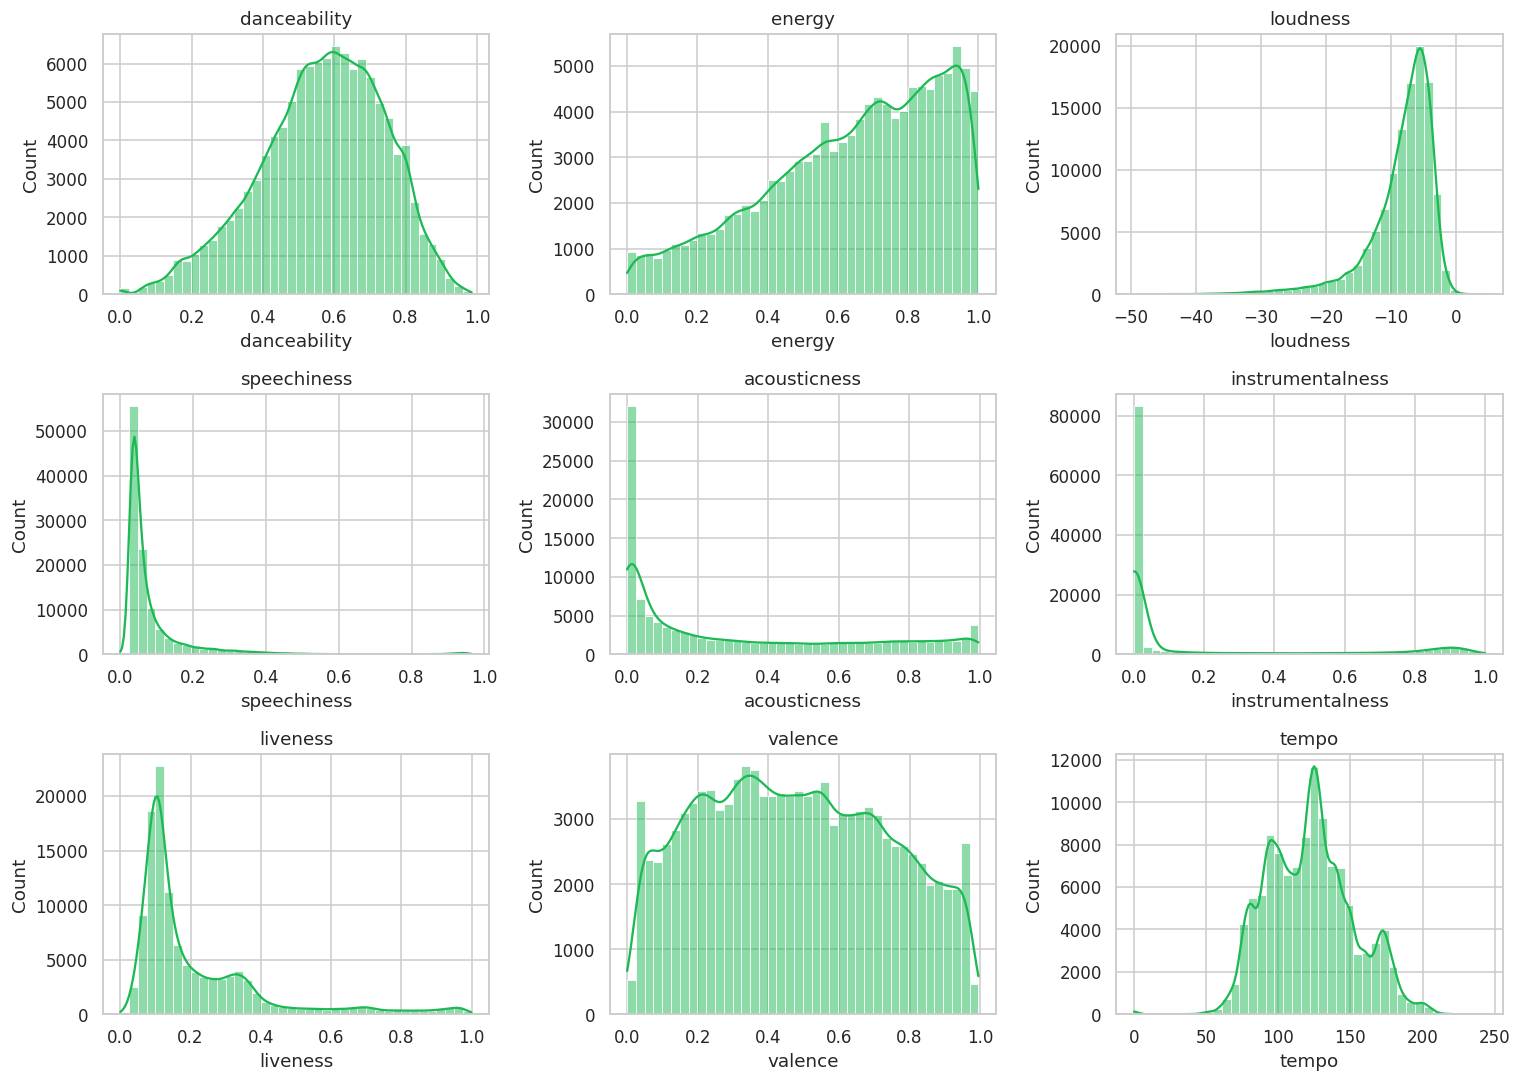

In [11]:
feats = ['danceability','energy','loudness','speechiness','acousticness',
         'instrumentalness','liveness','valence','tempo']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, f in zip(axes.flat, feats):
    sns.histplot(df[f], bins=40, kde=True, ax=ax, color="#1DB954")
    ax.set_title(f)
plt.tight_layout()
plt.savefig("fig_distribuicoes.png", dpi=110)
plt.show()


### 6.2 Correlação entre as features sonoras

Correlação entre as variáveis originais ajuda a responder GQ1: quais features carregam sinal
redundante e quais são candidatas fortes para diferenciar contexto.


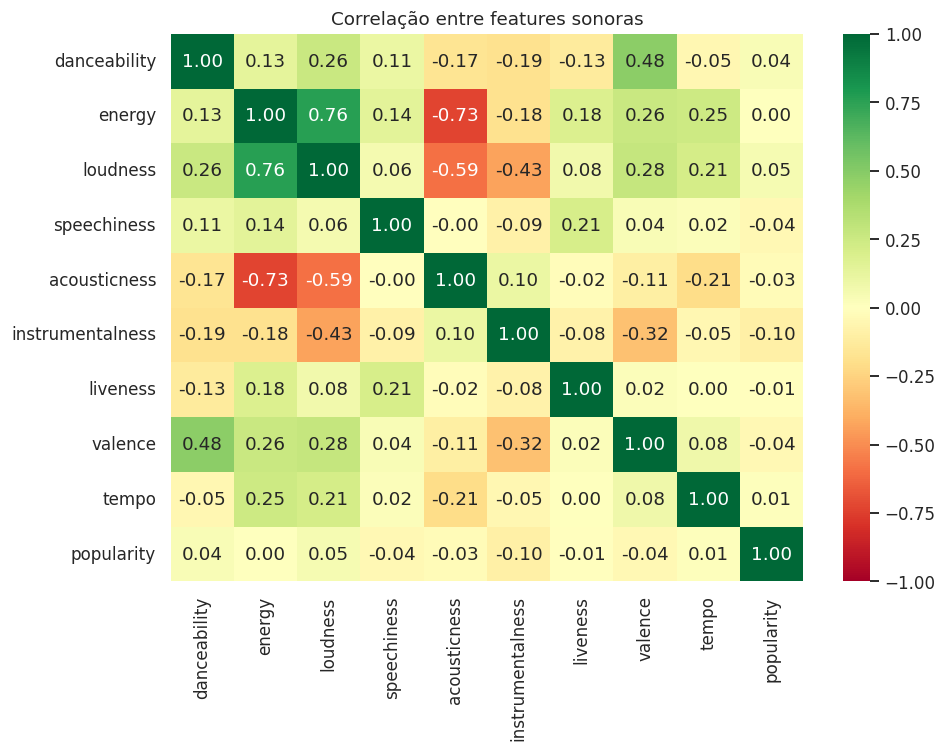

In [12]:
corr = df[feats + ['popularity']].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0, vmin=-1, vmax=1)
plt.title("Correlação entre features sonoras")
plt.tight_layout()
plt.savefig("fig_correlacao.png", dpi=110)
plt.show()


### 6.3 Proxy de contexto via `track_genre`

O dataset não tem rótulo de contexto, mas alguns **gêneros funcionam como proxy razoável**
para uma checagem inicial (não substitui a pesquisa com usuários da Fase 5):

- **Estudo (H2):** gênero `study`
- **Relaxamento (H3):** gênero `sleep`
- **Treino (H1):** não existe gênero "workout" no dataset; usamos um grupo de gêneros
  tipicamente associados a treino/energia alta (`edm`, `techno`, `hardstyle`, `dance`, `party`)
  como proxy, deixando claro que é uma aproximação mais fraca que as duas anteriores.


In [13]:
grupo_estudo = df[df['track_genre'] == 'study']
grupo_relax = df[df['track_genre'] == 'sleep']
grupo_treino = df[df['track_genre'].isin(['edm','techno','hardstyle','dance','party'])]
grupo_resto = df[~df['track_genre'].isin(['study','sleep','edm','techno','hardstyle','dance','party'])]

print("Tamanho dos grupos:")
print("study:", len(grupo_estudo))
print("sleep:", len(grupo_relax))
print("treino (proxy):", len(grupo_treino))
print("resto:", len(grupo_resto))


Tamanho dos grupos:
study: 1000
sleep: 1000
treino (proxy): 5000
resto: 106999


### 6.4 Checagem de H1 — Treino: `energy`, `tempo`, `danceability` maiores?

/tmp/ipykernel_509/25934286.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pd.concat([


/tmp/ipykernel_509/25934286.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pd.concat([


/tmp/ipykernel_509/25934286.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pd.concat([


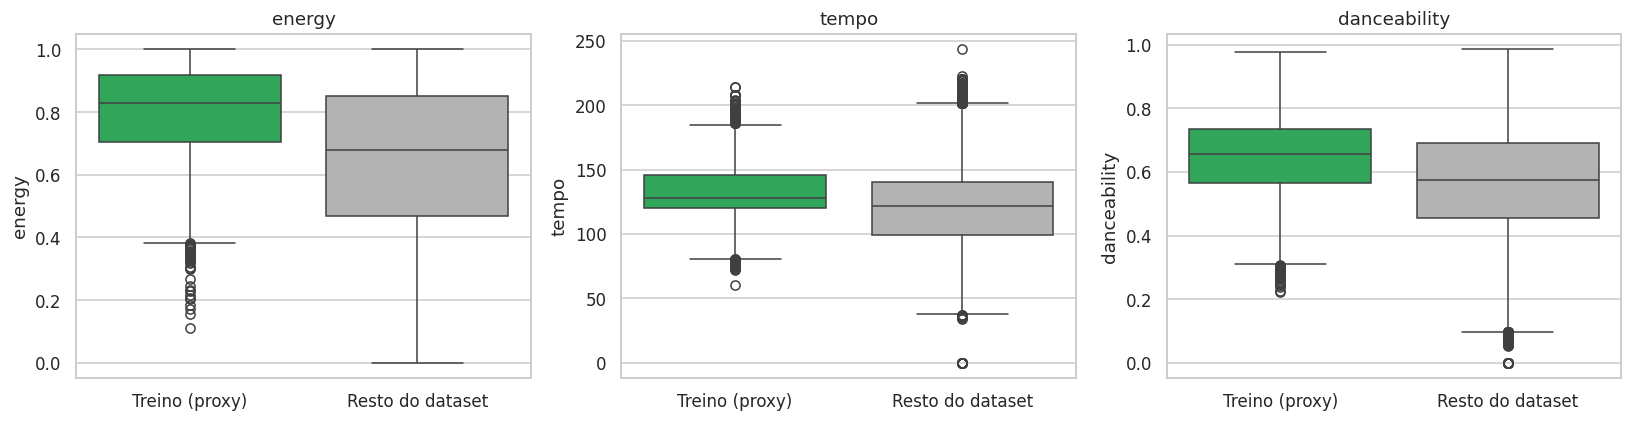

H1 [energy] — Mann-Whitney U (treino > resto): estatística=366695946.0, p-valor=0.00e+00
H1 [tempo] — Mann-Whitney U (treino > resto): estatística=316034416.5, p-valor=6.50e-105
H1 [danceability] — Mann-Whitney U (treino > resto): estatística=341536370.5, p-valor=4.90e-241


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, f in zip(axes, ['energy','tempo','danceability']):
    sns.boxplot(data=pd.concat([
        grupo_treino.assign(grupo='Treino (proxy)'),
        grupo_resto.assign(grupo='Resto do dataset')
    ]), x='grupo', y=f, ax=ax, palette=["#1DB954","#B3B3B3"])
    ax.set_title(f)
    ax.set_xlabel("")
plt.tight_layout()
plt.savefig("fig_h1_treino.png", dpi=110)
plt.show()

for f in ['energy','tempo','danceability']:
    t, p = stats.mannwhitneyu(grupo_treino[f], grupo_resto[f], alternative='greater')
    print(f"H1 [{f}] — Mann-Whitney U (treino > resto): estatística={t:.1f}, p-valor={p:.2e}")


### 6.5 Checagem de H2 — Estudo: `speechiness` menor, `instrumentalness` maior?

/tmp/ipykernel_509/3622582505.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pd.concat([
/tmp/ipykernel_509/3622582505.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pd.concat([


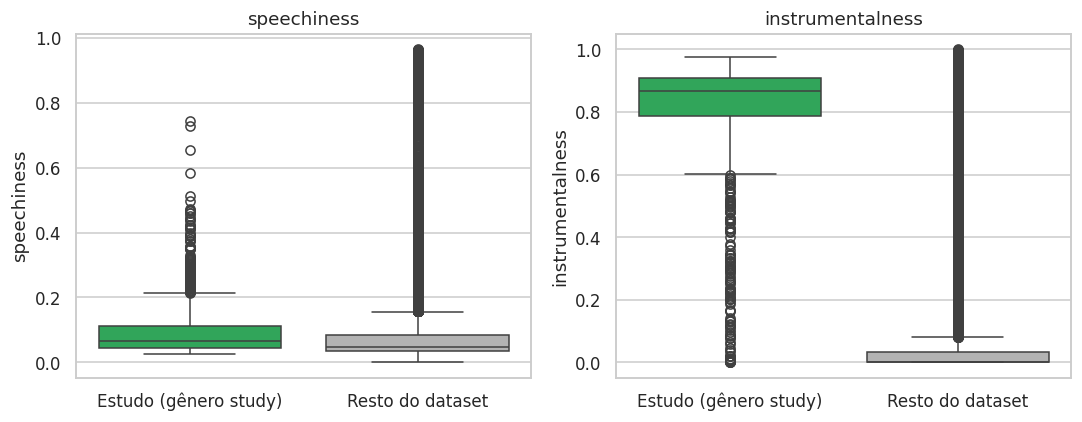

H2 [speechiness menor] — p-valor=1.00e+00
H2 [instrumentalness maior] — p-valor=0.00e+00


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, f in zip(axes, ['speechiness','instrumentalness']):
    sns.boxplot(data=pd.concat([
        grupo_estudo.assign(grupo='Estudo (gênero study)'),
        grupo_resto.assign(grupo='Resto do dataset')
    ]), x='grupo', y=f, ax=ax, palette=["#1DB954","#B3B3B3"])
    ax.set_title(f)
    ax.set_xlabel("")
plt.tight_layout()
plt.savefig("fig_h2_estudo.png", dpi=110)
plt.show()

t, p = stats.mannwhitneyu(grupo_estudo['speechiness'], grupo_resto['speechiness'], alternative='less')
print(f"H2 [speechiness menor] — p-valor={p:.2e}")
t, p = stats.mannwhitneyu(grupo_estudo['instrumentalness'], grupo_resto['instrumentalness'], alternative='greater')
print(f"H2 [instrumentalness maior] — p-valor={p:.2e}")


### 6.6 Checagem de H3 — Relaxamento: `energy`/`tempo` menores, `acousticness` maior?

/tmp/ipykernel_509/3205373661.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pd.concat([
/tmp/ipykernel_509/3205373661.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pd.concat([


/tmp/ipykernel_509/3205373661.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pd.concat([


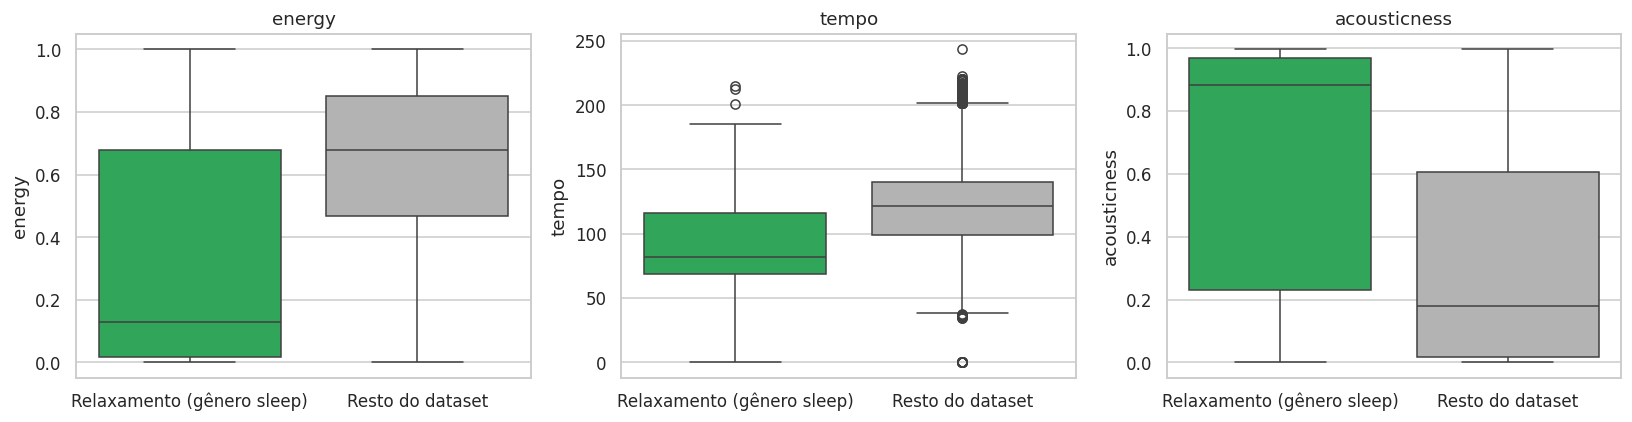

H3 [energy menor] — p-valor=1.36e-130
H3 [tempo menor] — p-valor=9.25e-181
H3 [acousticness maior] — p-valor=2.33e-155


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, f in zip(axes, ['energy','tempo','acousticness']):
    sns.boxplot(data=pd.concat([
        grupo_relax.assign(grupo='Relaxamento (gênero sleep)'),
        grupo_resto.assign(grupo='Resto do dataset')
    ]), x='grupo', y=f, ax=ax, palette=["#1DB954","#B3B3B3"])
    ax.set_title(f)
    ax.set_xlabel("")
plt.tight_layout()
plt.savefig("fig_h3_relax.png", dpi=110)
plt.show()

t, p = stats.mannwhitneyu(grupo_relax['energy'], grupo_resto['energy'], alternative='less')
print(f"H3 [energy menor] — p-valor={p:.2e}")
t, p = stats.mannwhitneyu(grupo_relax['tempo'], grupo_resto['tempo'], alternative='less')
print(f"H3 [tempo menor] — p-valor={p:.2e}")
t, p = stats.mannwhitneyu(grupo_relax['acousticness'], grupo_resto['acousticness'], alternative='greater')
print(f"H3 [acousticness maior] — p-valor={p:.2e}")


### 6.7 Visão geral: os 3 grupos-proxy nos scores derivados do PulseFlow

Checagem indireta: será que os próprios scores derivados (`workout_score`, `study_score`,
`relax_score`) já separam bem os 3 grupos-proxy, sem terem sido calibrados para isso?


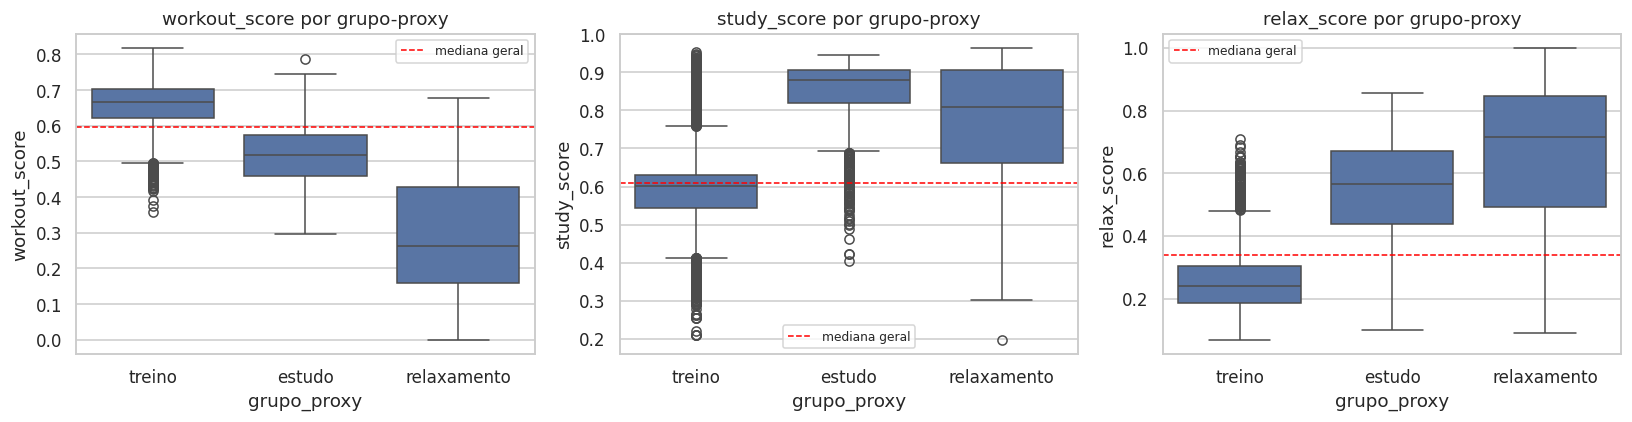

In [17]:
df_scored = df.copy()
df_scored['grupo_proxy'] = 'resto'
df_scored.loc[df_scored['track_genre'] == 'study', 'grupo_proxy'] = 'estudo'
df_scored.loc[df_scored['track_genre'] == 'sleep', 'grupo_proxy'] = 'relaxamento'
df_scored.loc[df_scored['track_genre'].isin(['edm','techno','hardstyle','dance','party']), 'grupo_proxy'] = 'treino'

subset = df_scored[df_scored['grupo_proxy'] != 'resto']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (score, grupo_alvo) in zip(axes, [('workout_score','treino'),('study_score','estudo'),('relax_score','relaxamento')]):
    sns.boxplot(data=subset, x='grupo_proxy', y=score, ax=ax,
                order=['treino','estudo','relaxamento'])
    ax.axhline(df[score].median(), color='red', linestyle='--', linewidth=1, label='mediana geral')
    ax.set_title(f"{score} por grupo-proxy")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("fig_scores_por_grupo.png", dpi=110)
plt.show()


## 7. Resultados preliminares por GQ

**GQ1 — Quais características melhor diferenciam os contextos?**
Os testes de Mann-Whitney acima (rodar o notebook para ver os p-valores atualizados) indicam
se cada feature separa estatisticamente o grupo-proxy do restante do dataset. Interpretação:

- p-valor baixo (< 0.05) → a diferença observada dificilmente é acaso, dado esse proxy de gênero.
- Isso é **evidência preliminar do dataset**, não confirmação de que usuários reais percebem essa
  diferença como "mais adequado para X" — isso só a Fase 5 (pesquisa com usuários) confirma.

**GQ2 e GQ3** dependem de dados que este dataset não tem (preferência do mesmo usuário em
contextos diferentes; perfil por tipo de trabalho) — ficam para a Fase 5 do plano de investigação.


## 8. Limitações desta etapa

- `track_genre` é um **proxy**, não um rótulo de contexto real — resultados de H1–H3 aqui são
  indícios, não confirmação.
- Os *scores* (`workout_score`, `study_score`, etc.) são heurísticas de feature engineering,
  ainda **não calibradas** com feedback humano.
- Uma mesma `track_id` aparece em múltiplos gêneros — isso foi mantido de propósito, mas deve
  ser levado em conta em qualquer modelagem futura (evitar vazamento de dados entre treino/teste
  por causa da mesma faixa aparecendo em ambos).
- Ainda não há EDA de duplicatas de artista/popularidade, PCA exploratória, nem modelo — ficam
  para as Fases 4 (hipóteses formais) e 6 (baseline/ML) do plano de investigação.


## 9. Próximos passos (conforme plano de investigação do PulseFlow)

1. Formalizar H0/H1 estatisticamente (Fase 4) com os resultados acima.
2. Desenhar a coleta de dados de usuários / rotulagem (Fase 5) para validar GQ2 e GQ3, e para dar
   verdade de referência real às hipóteses H1–H3 (hoje testadas apenas via proxy de gênero).
3. Baseline e modelo de classificação/ranking por contexto (Fase 6), usando as features validadas
   aqui como candidatas principais.
4. **Não** usar os números ilustrativos das artes de mockup como resultado — usar os valores
   gerados por este notebook.
